In [250]:
# Car Price Prediction Model:
# here is the project plan:
# 1- prepare the data and do EDA (exploratory data analysis) ==> cleaning the data, missing values, duplicates, etc.
# 2- using linear regression to predict the prices (we train the model based on linear regression).
# 3- building a clear understanding of the internals of linear regression.
# 4- evaluate the model output using RMSE (root mean squared error, a common evaluation metric for regression models).
# 5- feature engineering.
# 6- regularization.
# 7- using the model.

In [251]:
import numpy as np
import pandas as pd

In [252]:
df = pd.read_csv("data.csv")

In [253]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [254]:
# first, to make the data cleaner, we replace all spaces with underscores and we lowercase all the column names.
df.columns = df.columns.str.lower().str.replace(pat=" ", repl="_")

In [255]:
# now, we start to normalize the data of the dataframe as well.
# first, we identify the string columns.
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [256]:
# the columns which have 'object' datatype are the ones that contain strings.
# this is how we find the columns that contain string values:
strings = list(df.dtypes[df.dtypes == "object"].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [257]:
for column in strings:
    df[column] = df[column].str.lower().str.replace(pat= " ", repl="_")

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [258]:
# Exploratory Data Analysis:
# first, we take a look at the values of each column:
for column in df.columns:
    print(column)
    print(df[column].unique()[:5])
    print(df[column].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [259]:
# now, we want to visualize the dataset using matplotlib and seaborn to further understand the data:
import matplotlib.pyplot as plt
import seaborn as sns
# we use the line below, to see the graphs inside the jupyter notebook environment, not in a seperate window:
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

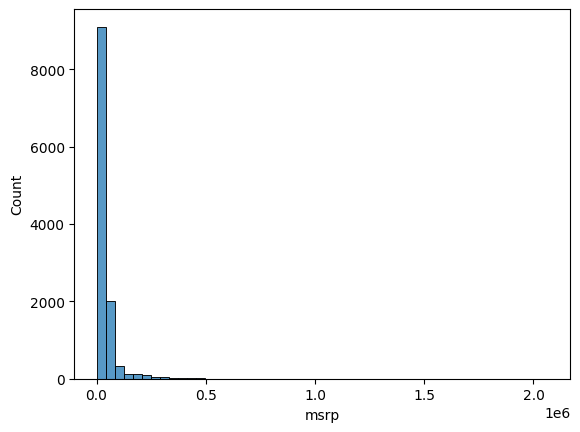

In [260]:
# for example, we want to take a look at the distribution of the prices of the cars using a histogram:
sns.histplot(df.msrp, bins=50)
# the 'bins' argument is the number of columns in the histogram, so we reduce it to make the histogram more understandable.

In [261]:
# the above histogram shows that the distribution of our data is a long-tail distribution.
# A long-tail distribution describes a situation where most observations are concentrated around relatively small/common values,
# but a small number of observations extend very far into the high-value range.
# we have right-skewed and left-skewed long-tail distribution, which means the right/left side streches much farther,
# in comparison with the normal distribution. these are called long right/left tail distributions.

<Axes: xlabel='msrp', ylabel='Count'>

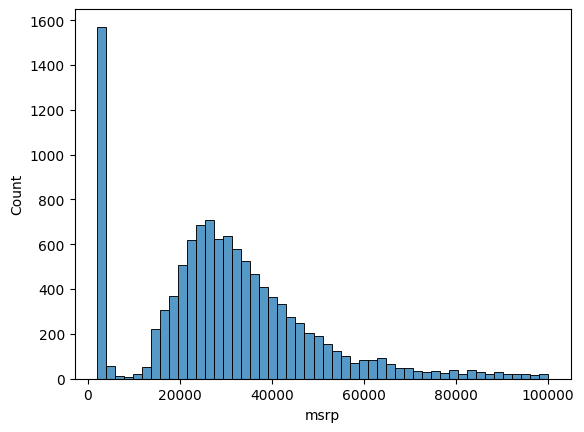

In [262]:
# to get a better look at the more common values in our dataframes, we can look at values < 100000:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

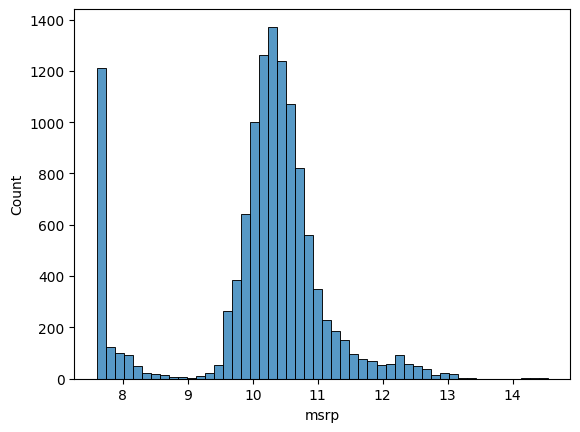

In [263]:
# the long tail distribution is not really good for machine learning, because the tail confuses our model.
# to get rid of the long tail distribution, we usually apply the logarithmic distribution.
# this way, we calculate the log of the values, so that the data becomes much more compact.
# if we use the normal logarithm function and we have '0' in our data, the value would be -inf,
# so to prevent this from happening, we use log1p instead, which calculates log(x+1) for each x.
logarithmic_prices = np.log1p(df.msrp)
sns.histplot(logarithmic_prices, bins=50)
# now, this is way more compact and it's closer to the normal distribution and it does not confuse our model anymore. 

In [264]:
# last but not least, we will look at the missing values.
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [265]:
# Now, we start setting up the Validation Framework (60 training, 20 validation, 20 test)
number_of_all_records = len(df)
number_of_validation_records = int(number_of_all_records * 0.2)
number_of_test_records = int(number_of_all_records * 0.2)
number_of_training_records = number_of_all_records - number_of_test_records - number_of_validation_records

In [266]:
df_training = df.iloc[number_of_training_records:]
df_validation = df.iloc[number_of_training_records:number_of_validation_records + number_of_training_records]
df_test = df.iloc[number_of_validation_records + number_of_training_records:]

In [267]:
# the initial dataset might be sequential, so to make the distribution of data more uniform,
# we will shuffle the dataframe before choosing the subsets (test, validation, training).
# to do so, we can shuffle the indices 1 to n-1, and then use iloc to randomly choose the records. 
indices = np.arange(number_of_all_records)
# to make sure the results are reproducable (the dataframes would be the same each time we run the code),
# we usually set a random seed before shuffling the indices list.
np.random.seed(10)
np.random.shuffle(indices)

In [268]:
random_indices_training = indices[:number_of_training_records]
random_indices_validation = indices[number_of_training_records: number_of_training_records + number_of_validation_records]
random_indices_test = indices[ number_of_training_records + number_of_validation_records:]

df_training = df.iloc[random_indices_training]
df_validation = df.iloc[random_indices_validation]
df_test = df.iloc[random_indices_test]

In [269]:
# now, we can use the reset_index method to make the indices of the three subsets start from 0:
df_training.reset_index(drop=True, inplace=True)
df_validation.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

In [270]:
y_training = np.log1p(df_training.msrp.values)
y_validation = np.log1p(df_validation.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [271]:
# now, we should remove the variables from our datasets:
del df_training['msrp']
del df_validation['msrp']
del df_test['msrp']

In [272]:
def linear_regression(xi, w0, w):
    n = len(xi)
    prediction = w0
    for i in range(n):
        prediction += w[i] * xi[i]

    return np.expm1(prediction)

In [273]:
# we can use dot product, to make the operation more readable.
# so, we first define the dot_product method:

def dot_product(xi, w):
    n = len(xi)
    result = 0.0
    for i in range(n):
        result += xi[i] * w[i]

    return result

# we could also use the dot() method of the numpy library.

In [274]:
# here is the vector form of the function:

def linear_regression(xi, w0, w):

    return w0 + dot_product(xi, w)

In [275]:
# to make it more clear, we can insert a '1' at index 0 in the xi vector,
# so that we can show the result as the vector multiplication of xi and w (including w0).

def linear_regression_instance(xi, w0, w):
    w.insert(0, w0)
    xi.insert(0, 1)

    return dot_product(w, xi)

In [276]:
# now, we can transform the function into the matrix-vector multiplication form:

def linear_regression_matrix(x, w):
    predictions = []
    number_of_cars = len(x)

    for i in range(number_of_cars):
        predictions.append(dot_product(x[i], w))

    return predictions

In [277]:
# now, we will go through the process of training a linear regression model:
# first, we define a function to add a column of ones to our X matrix:

def modify_X(X):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    return X

# w = ((((X^T X) ^ -1) X^T) y)

def find_linear_regression_coefficients(X, y):
    X = modify_X(X)
    xt = X.T
    xt_x = xt.dot(X)
    xt_x_inverse = np.linalg.inv(xt_x)
    xt_x_inverse_xt = xt_x_inverse.dot(xt)
    w = xt_x_inverse_xt.dot(y)

    return w


In [278]:
# now, we want to train our model using linear regression with the folllowing features:
base = ["engine_hp", "engine_cylinders", "highway_mpg", "city_mpg", "popularity"]

In [279]:
# now, let's extract the values we want to work with:
X_training = df_training[base].values
# remember we have y_training ready:
y_training

array([10.38794867, 10.21100902, 12.29175022, ..., 10.28827365,
       11.54540234, 10.23820826], shape=(7150,))

In [280]:
weights = find_linear_regression_coefficients(X_training, y_training)
weights

array([nan, nan, nan, nan, nan, nan])

In [281]:
# we see that the output of the linear regression function is all nan values (not a number).
# this happens because we have null/nan values in our dataframe that we have used for training our model:
df_training[base].isnull().sum()

engine_hp           39
engine_cylinders    23
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [282]:
# one way to solve this, is to fill the nan cells with zeros.
# this way, the model ignores these features when being trained.
X_training = df_training[base].fillna(0).values
# there are better ways to fill the missing values (using mean, mode, median, etc.), but for now we skip it.

In [283]:
# now we can see the training process has been completed succesfully.
weights = find_linear_regression_coefficients(X_training, y_training)
w0, w = weights[0], weights[1:]
w0, w

(np.float64(7.550682059939393),
 array([ 9.24662284e-03, -1.24616495e-01,  4.46779339e-02, -1.08572520e-02,
        -5.34164211e-06]))

<Axes: ylabel='Count'>

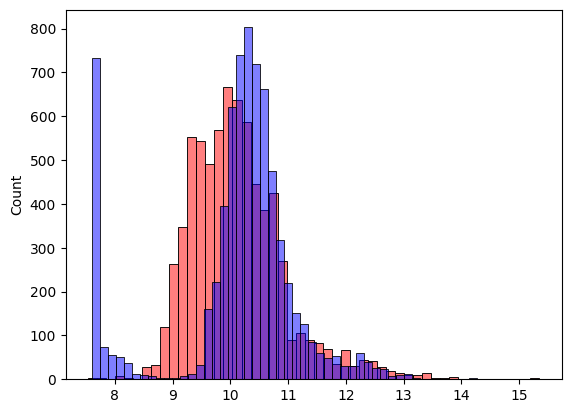

In [284]:
# now, we can see how similar would our predictions be to the actual values of the taret variable:
y_prediction = w0 + X_training.dot(w)
sns.histplot(y_prediction, color='red', bins=50, alpha=0.5)
sns.histplot(y_training, color='blue', bins=50, alpha=0.5)

In [285]:
# Evaluating our regression model using RMSE (root mean squared error):
from math import sqrt, pow

def RMSE(y_real, y_predicted):
    n = len(y_real)
    total = 0
    for i in range(n):
        total += pow((y_real[i] - y_predicted[i]), 2)

    total /= n
    total = sqrt(total)
    return total

def RMSE_optimal(y_real, y_predicted):
    error = y_real - y_predicted
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [286]:
RMSE(y_training, y_prediction)

0.7504760397364797

In [287]:
# now, let's validate our model using the validation dataset:
def prepare_X(dataframe):
    dataframe_numbers = dataframe[base]
    X = dataframe_numbers.fillna(0).values

    return X


In [288]:
X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.8094029088963357

In [289]:
# Now, we will go through simple feature engineering.
# let's first modify our prepare function:
def prepare_X(df):

    dataframe = df.copy()
    features = base.copy()

    dataframe['age'] = 2017 - dataframe.year
    features.append('age')
    dataframe_numbers = dataframe[features]
    X = dataframe_numbers.fillna(0).values

    return X

In [290]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients(X_training, y_training)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.5275056513957488

<Axes: ylabel='Count'>

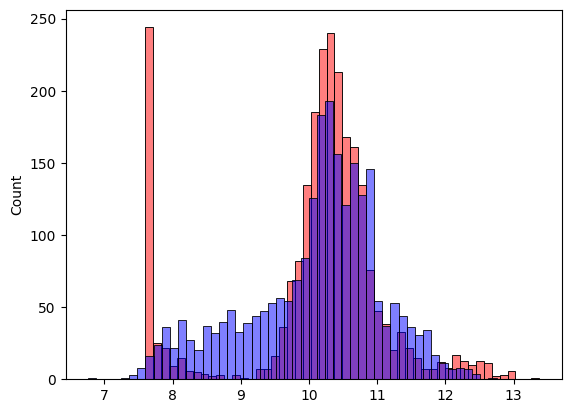

In [291]:
sns.histplot(y_validation, color='red', bins=50, alpha=0.5)
sns.histplot(y_val_prediction, color='blue', bins=50, alpha=0.5)

In [292]:
# now we will learn about how we can use the categorical variables for our prediction model:
# for categorical variables, we add binary columns for each possible value of the variable.
# so, let's modify our prepare_X function to do this as well:

def prepare_X(df):

    dataframe = df.copy()
    features = base.copy()

    dataframe['age'] = 2017 - dataframe.year
    features.append('age')

    for n in [2, 3, 4]:
        dataframe['num_doors_%s' %n] = dataframe['number_of_doors'].apply(lambda x: 1 if x == n else 0)
    features.extend(['num_doors_2', 'num_doors_3', 'num_doors_4'])

    dataframe_numbers = dataframe[features]
    X = dataframe_numbers.fillna(0).values

    return X

In [293]:
prepare_X(df_training)

array([[235.,   6.,  24., ...,   0.,   0.,   1.],
       [274.,   4.,  27., ...,   1.,   0.,   0.],
       [515.,  12.,  15., ...,   1.,   0.,   0.],
       ...,
       [170.,   4.,  35., ...,   0.,   0.,   1.],
       [430.,   8.,  19., ...,   1.,   0.,   0.],
       [138.,   4.,  33., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [294]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients(X_training, y_training)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.5303458665460982

In [297]:
# now we can include the Make of the cars as well:
car_makes = list(df.make.value_counts().head().index)

In [305]:
def prepare_X(df):

    dataframe = df.copy()
    features = base.copy()

    dataframe['age'] = 2017 - dataframe.year
    features.append('age')

    for n in [2, 3, 4]:
        dataframe['num_doors_%s' %n] = dataframe['number_of_doors'].apply(lambda x: 1 if x == n else 0)
    features.extend(['num_doors_2', 'num_doors_3', 'num_doors_4'])

    for make in car_makes:
        dataframe['make_%s' %make] = dataframe['make'].apply(lambda x: 1 if x == make else 0)
        features.append('make_%s' %make)

    dataframe_numbers = dataframe[features]
    X = dataframe_numbers.fillna(0).values

    return X

In [306]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients(X_training, y_training)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.5367984780829588

In [307]:
# now, let's add more categorical variables to our model:
categories = {}
list_of_categories = ['engine_fuel_type', "transmission_type", "driven_wheels",
                      "market_category", "vehicle_size", "vehicle_style"]

for category in list_of_categories:
    categories[category] = list(df[category].value_counts().head().index)

In [311]:
def prepare_X(df):

    dataframe = df.copy()
    features = base.copy()

    dataframe['age'] = 2017 - dataframe.year
    features.append('age')

    for n in [2, 3, 4]:
        dataframe['num_doors_%s' %n] = dataframe['number_of_doors'].apply(lambda x: 1 if x == n else 0)
    features.extend(['num_doors_2', 'num_doors_3', 'num_doors_4'])

    for make in car_makes:
        dataframe['make_%s' %make] = dataframe['make'].apply(lambda x: 1 if x == make else 0)
        features.append('make_%s' %make)

    for category, values in categories.items():
        for value in values:
            dataframe["%s_%s" % (category, value)] = dataframe[category].apply(lambda x: 1 if x == value else 0)
            features.append("%s_%s" % (category, value))


    dataframe_numbers = dataframe[features]
    X = dataframe_numbers.fillna(0).values

    return X

In [312]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients(X_training, y_training)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

109.08944807167255

In [316]:
# so, now we see that the predictions of the model got fucked up. 
# this is because of the dummy-variable trap, and we are going to fix it using normalization.

def find_linear_regression_coefficients_regular(X, y, landa = 0.001):
    X = modify_X(X)
    xt = X.T
    xt_x = xt.dot(X)
    xt_x = xt_x + landa * np.eye(xt_x.shape[0])
    xt_x_inverse = np.linalg.inv(xt_x)
    xt_x_inverse_xt = xt_x_inverse.dot(xt)
    w = xt_x_inverse_xt.dot(y)

    return w

In [323]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients_regular(X_training, y_training)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.5263412789627556

In [334]:
# Tuning a Model (finding the best possible value for landa):
def find_best_landa():
    minimum_RMSE = 1
    best_landa = 0.01
    for num in [0.0001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]:
        X_training = prepare_X(df_training)
        w_all = find_linear_regression_coefficients_regular(X_training, y_training, landa = num)
        w0, w = w_all[0], w_all[1:]

        X_validation = prepare_X(df_validation)
        y_val_prediction = w0 + X_validation.dot(w)
        temp = RMSE(y_validation, y_val_prediction)
        if temp <= minimum_RMSE:
            minimum_RMSE = temp
            best_landa = num

        return best_landa, minimum_RMSE

best_landa, minimum_RMSE = find_best_landa()
print(f"The Best Value For Landa Is {best_landa}, And The RMSE For This Landa is {minimum_RMSE}")

The Best Value For Landa Is 0.0001, And The RMSE For This Landa is 0.526373260093484


In [333]:
X_training = prepare_X(df_training)
w_all = find_linear_regression_coefficients_regular(X_training, y_training, landa=10)
w0, w = w_all[0], w_all[1:]

X_validation = prepare_X(df_validation)
y_val_prediction = w0 + X_validation.dot(w)
RMSE(y_validation, y_val_prediction)

0.47743683758131295

In [339]:
# Testing The Model:
# now, we test the model by predicting the car prices on our test dataset:
# in this step, we train the model on Training + Validation dataset and then we test it on the test dataset:

df_full_training = pd.concat([df_training, df_validation])
df_full_training.reset_index(drop=True, inplace=True)
X_full_training = prepare_X(df_full_training)
y_full_training = np.concat([y_training, y_validation])


w_all = find_linear_regression_coefficients_regular(X_full_training, y_full_training, landa=0.1)
w0, w = w_all[0], w_all[1:]

X_test = prepare_X(df_test)
y_test_prediction = w0 + X_test.dot(w)
RMSE(y_test, y_test_prediction)

0.4607412949797996

In [356]:
# now, let's use the model to predict the price of a car:

test_car = df_test.iloc[10].to_dict()
df_test_car = pd.DataFrame([test_car])
X_test_car = prepare_X(df_test_car)
y_prediction_car = w0 + X_test_car.dot(w)
print(np.expm1(y_prediction_car))
print(np.expm1(y_test[10]))

[3644.34748097]
2388.000000000001
